# Ensemble Models and Techniques with Hyperparameter Tuning, PR Curves, and Class Separation Diagrams


This notebook demonstrates various ensemble models on a real-world classification dataset with baseline and tuned versions.

We'll evaluate **Random Forest**, **XGBoost**, **CatBoost**, **LightGBM**, and a **Stacking Classifier** combining K-Nearest Neighbors, Ridge Classifier, and SVC.

Each model will be visualized.


## Install Required Libraries

In [1]:
!pip install xgboost catboost lightgbm scikit-learn matplotlib -q

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_curve, roc_curve, auc, average_precision_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [3]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load the dataset

In [4]:
# We will use Telco Customer Churn Dataset https://www.kaggle.com/datasets/blastchar/telco-customer-churn
# Load the Telco Customer Churn dataset
data_path = Path('/content/drive/MyDrive/courses/ml_basics/datasets/Telco Customer Churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(data_path)

# Drop customer ID column as it's not relevant for prediction
df = df.drop(columns=['customerID'])

# Convert target column 'Churn' to binary (1 for Yes, 0 for No)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

df.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043.000000
unique,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,NaN
top,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,NaN
freq,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,NaN
mean,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,0.265370
std,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,0.441561
min,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,0.000000
25%,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,0.000000
50%,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,0.000000
75%,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,1.000000


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [6]:
df.nunique()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3


In [7]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


In [8]:
# Identify categorical columns based on unique value count (10 or fewer unique values)
unique_counts = df.nunique()
categorical_cols = unique_counts[unique_counts <= 5].index.tolist()
categorical_cols.remove('Churn')  # Remove target from categorical columns

# Identify numeric columns (those not identified as categorical)
numeric_cols = [col for col in df.columns if col not in categorical_cols and col != 'Churn']

# Convert columns that should be numeric to numeric values, setting errors='coerce' to replace non-numeric entries with NaN
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Impute missing values
numeric_imputer = SimpleImputer(strategy='mean')
df[numeric_cols] = numeric_imputer.fit_transform(df[numeric_cols])
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

# Encode categorical columns (not required for CatBoost, so we'll keep separate encodings)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [9]:
categorical_cols

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [10]:
numeric_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [11]:
# Split features and target for encoded dataset and non-encoded for CatBoost
X = df_encoded.drop('Churn', axis=1)
y = df['Churn']


In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
# Standardize numeric features only for models that need scaling
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [14]:
# Display identified categorical and numeric columns
print("Categorical Columns (5 or fewer unique values):", categorical_cols)
print("Numeric Columns:", numeric_cols)

Categorical Columns (5 or fewer unique values): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric Columns: ['tenure', 'MonthlyCharges', 'TotalCharges']


In [15]:
# Function to evaluate model performance
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')  # For binary classification
    recall = recall_score(y_test, y_pred, average='binary')  # For binary classification
    f1 = f1_score(y_test, y_pred, average='binary')  # For binary classification
    average_precision = average_precision_score(y_test, y_probs)
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))
    plot_pr_curve(model, X_test, y_test, name)
    plot_roc_curve(model, X_test, y_test, name)
    #plot_class_separation(model, X_test, y_test, name)
    plot_density(y_test, y_probs, name)
    return {
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'AUC': roc_auc,
        'Average Precision': average_precision
    }

# Plot PR Curve
def plot_pr_curve(model, X_test, y_test, model_name="Model"):
    y_probs = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    average_precision = average_precision_score(y_test, y_probs)
    plt.plot(recall, precision, marker='.', label=f'{model_name} (AP={average_precision:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve for {model_name}')
    plt.legend()
    plt.show()

# Plot ROC Curve
def plot_roc_curve(model, X_test, y_test, model_name="Model"):
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='b', label=f'{model_name} (AUC={roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='r', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {model_name}')
    plt.legend()
    plt.show()

# Plot Class Separation using PCA
def plot_class_separation(model, X_test, y_test, model_name="Model"):
    pca = PCA(n_components=2)
    X_test_2d = pca.fit_transform(X_test)
    y_pred = model.predict(X_test)
    plt.scatter(X_test_2d[y_test == 0][:, 0], X_test_2d[y_test == 0][:, 1], alpha=0.6, label='Class 0')
    plt.scatter(X_test_2d[y_test == 1][:, 0], X_test_2d[y_test == 1][:, 1], alpha=0.6, label='Class 1')
    plt.scatter(X_test_2d[y_pred != y_test][:, 0], X_test_2d[y_pred != y_test][:, 1], color='red', marker='x', label='Misclassified')
    plt.legend()
    plt.title(f'Class Separation Plot for {model_name}')
    plt.show()

# Plot density of predicted probabilities
def plot_density(y_test, y_probs, model_name="Model"):
    sns.kdeplot(y_probs[y_test == 0], label='Class 0', fill=True)
    sns.kdeplot(y_probs[y_test == 1], label='Class 1', fill=True)
    plt.xlabel('Predicted Probability')
    plt.ylabel('Density')
    plt.title(f'Density Plot for Predicted Probabilities - {model_name}')
    plt.legend()
    plt.show()

# Function to collect metrics for comparison
def collect_metrics(models, X_test, y_test):
    metrics = []
    for model in models:
        metrics.append(evaluate_model(model['model'], X_test, y_test, name=model['name']))
    return pd.DataFrame(metrics)

# 1. Random Forest - Baseline vs Tuned


--- Random Forest (Baseline) ---
Accuracy: 0.792238523426408
Precision: 0.6674937965260546
Recall: 0.4686411149825784
F1 Score: 0.5506653019447287
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.82      0.91      0.86      1539
     Class 1       0.67      0.47      0.55       574

    accuracy                           0.79      2113
   macro avg       0.74      0.69      0.71      2113
weighted avg       0.78      0.79      0.78      2113



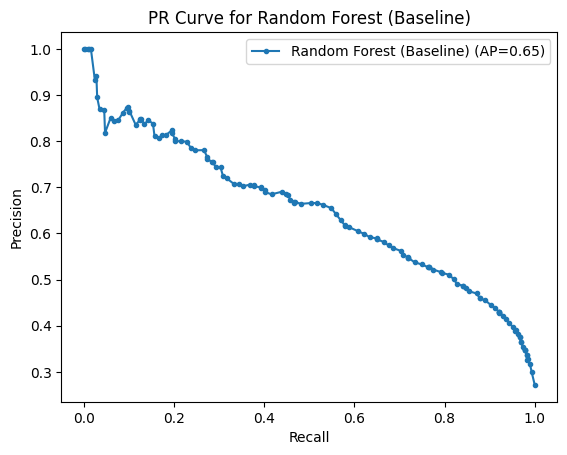

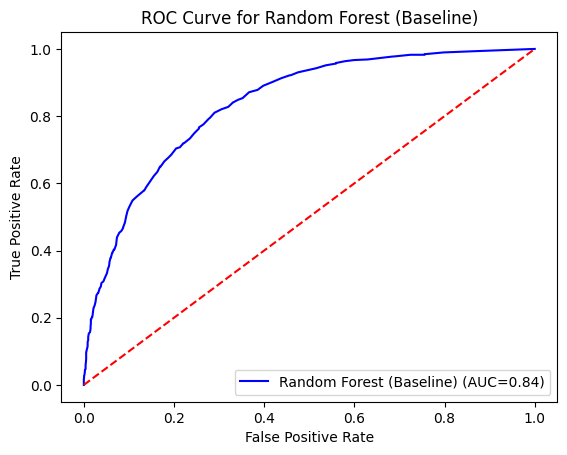

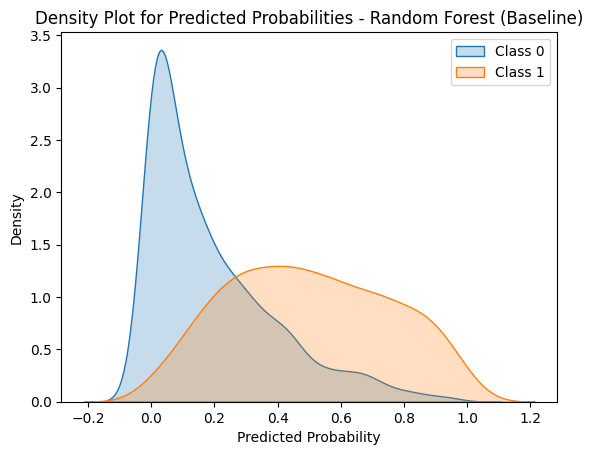

{'Model': 'Random Forest (Baseline)',
 'Accuracy': 0.792238523426408,
 'Precision': 0.6674937965260546,
 'Recall': 0.4686411149825784,
 'F1 Score': 0.5506653019447287,
 'AUC': 0.8366750208855471,
 'Average Precision': 0.6493899208633593}

In [16]:
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
evaluate_model(rf_clf, X_test, y_test, name="Random Forest (Baseline)")


--- Random Forest (Tuned) ---
Accuracy: 0.8031235210601041
Precision: 0.6845794392523364
Recall: 0.5104529616724739
F1 Score: 0.5848303393213573
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.83      0.91      0.87      1539
     Class 1       0.68      0.51      0.58       574

    accuracy                           0.80      2113
   macro avg       0.76      0.71      0.73      2113
weighted avg       0.79      0.80      0.79      2113



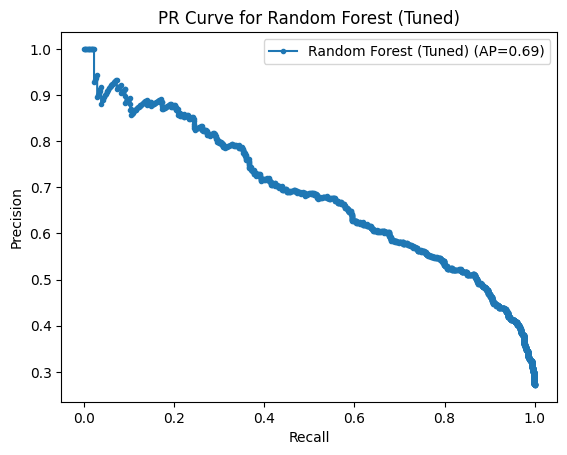

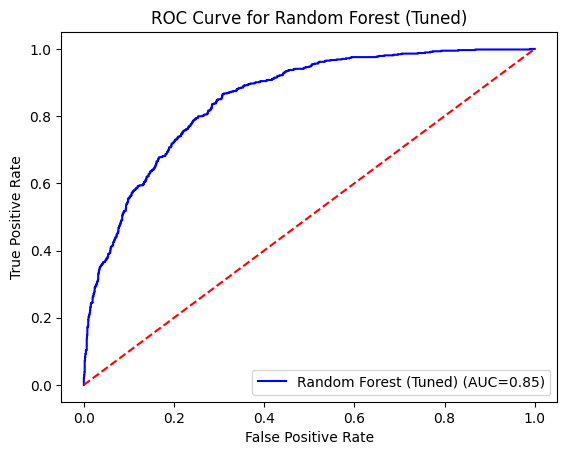

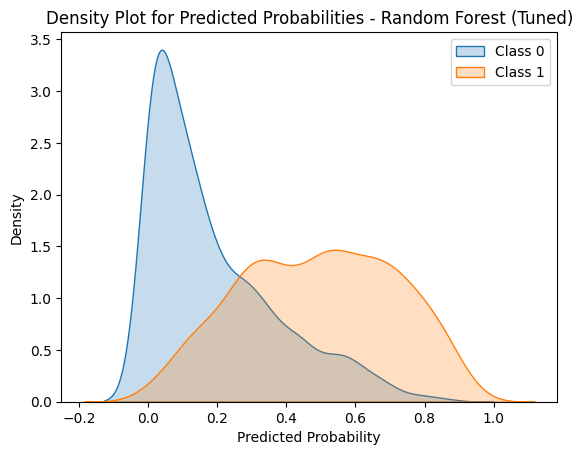

{'Model': 'Random Forest (Tuned)',
 'Accuracy': 0.8031235210601041,
 'Precision': 0.6845794392523364,
 'Recall': 0.5104529616724739,
 'F1 Score': 0.5848303393213573,
 'AUC': 0.8526504834806076,
 'Average Precision': 0.6860841949233383}

In [17]:
# Hyperparameter tuning for Random Forest
rf_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='f1')
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
evaluate_model(rf_best, X_test, y_test, name="Random Forest (Tuned)")

In [28]:
rf_grid.best_params_

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

# 2. XGBoost - Baseline vs Tuned

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [19:42:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



--- XGBoost (Baseline) ---
Accuracy: 0.7927117841930904
Precision: 0.6452991452991453
Recall: 0.5261324041811847
F1 Score: 0.5796545105566219
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.83      0.89      0.86      1539
     Class 1       0.65      0.53      0.58       574

    accuracy                           0.79      2113
   macro avg       0.74      0.71      0.72      2113
weighted avg       0.78      0.79      0.79      2113



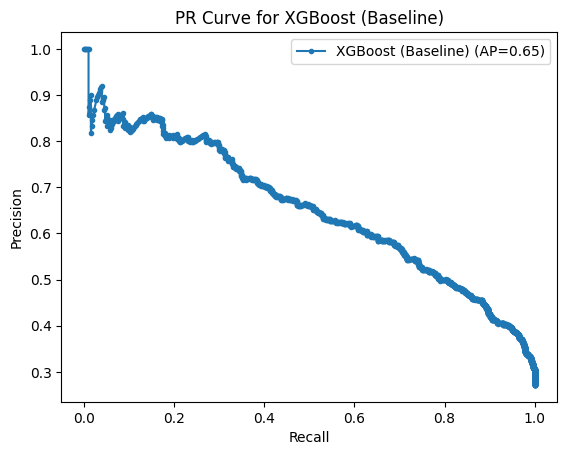

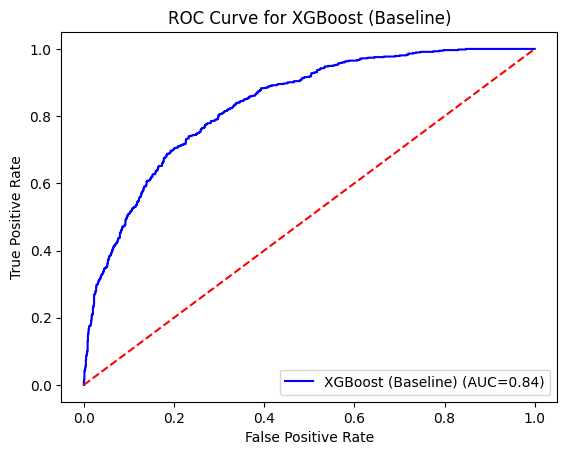

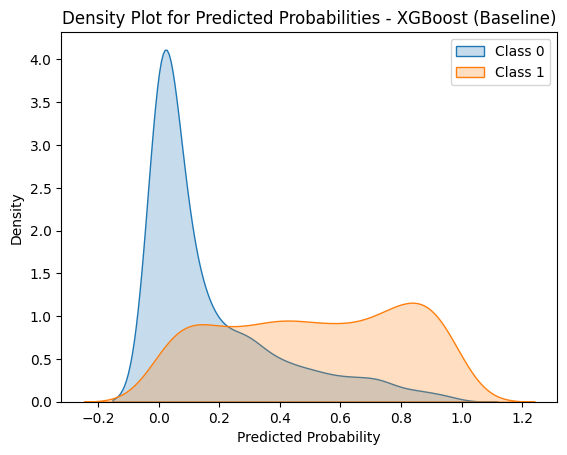

{'Model': 'XGBoost (Baseline)',
 'Accuracy': 0.7927117841930904,
 'Precision': 0.6452991452991453,
 'Recall': 0.5261324041811847,
 'F1 Score': 0.5796545105566219,
 'AUC': 0.8350319113049108,
 'Average Precision': 0.6535536418559013}

In [18]:
xgb_clf = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(X_train, y_train)
evaluate_model(xgb_clf, X_test, y_test, name="XGBoost (Baseline)")


--- XGBoost (Tuned) ---
Accuracy: 0.8035967818267865
Precision: 0.6827586206896552
Recall: 0.5174216027874564
F1 Score: 0.5887016848364718
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.83      0.91      0.87      1539
     Class 1       0.68      0.52      0.59       574

    accuracy                           0.80      2113
   macro avg       0.76      0.71      0.73      2113
weighted avg       0.79      0.80      0.79      2113



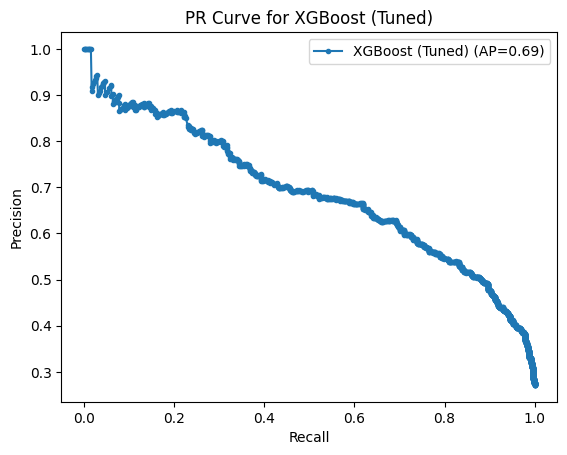

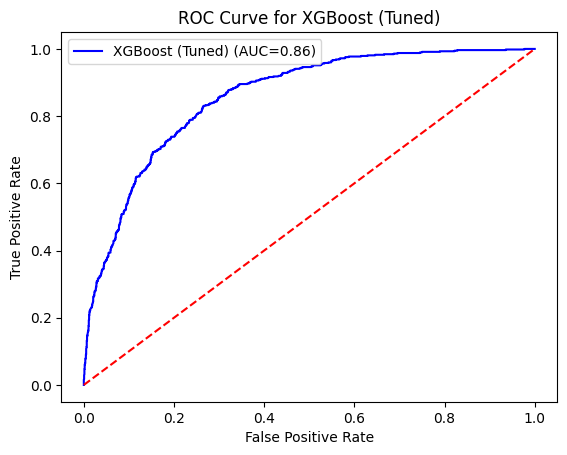

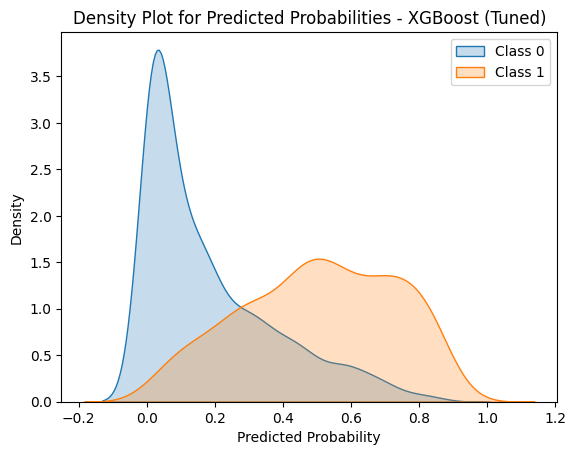

{'Model': 'XGBoost (Tuned)',
 'Accuracy': 0.8035967818267865,
 'Precision': 0.6827586206896552,
 'Recall': 0.5174216027874564,
 'F1 Score': 0.5887016848364718,
 'AUC': 0.8574383112252176,
 'Average Precision': 0.6885214169192102}

In [19]:
# Hyperparameter tuning for XGBoost
xgb_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), xgb_params, cv=5, scoring='f1')
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_
evaluate_model(xgb_best, X_test, y_test, name="XGBoost (Tuned)")


# 3. Stacking Classifier - Baseline


--- Stacking Classifier (Baseline) ---
Accuracy: 0.8017037387600567
Precision: 0.6858513189448441
Recall: 0.49825783972125437
F1 Score: 0.5771947527749748
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.83      0.91      0.87      1539
     Class 1       0.69      0.50      0.58       574

    accuracy                           0.80      2113
   macro avg       0.76      0.71      0.72      2113
weighted avg       0.79      0.80      0.79      2113



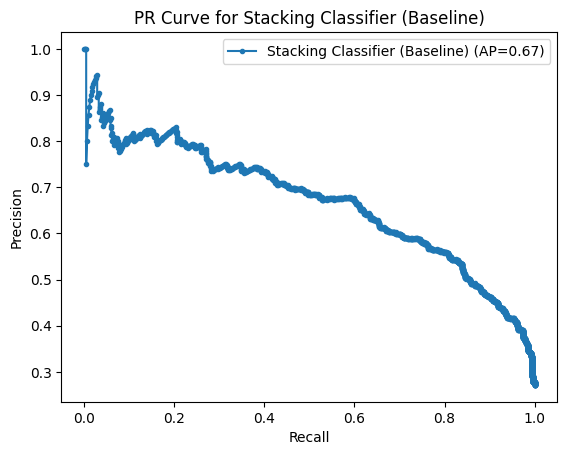

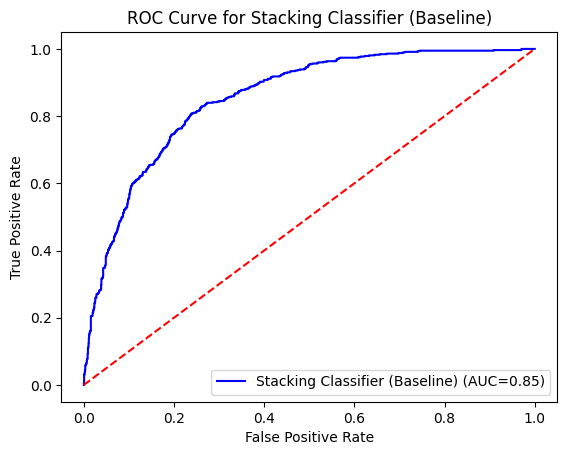

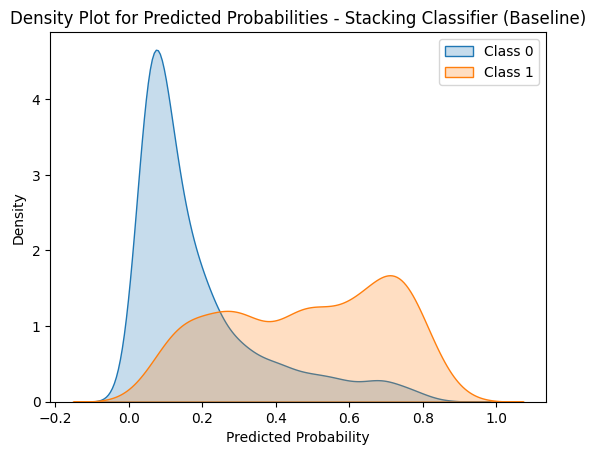

{'Model': 'Stacking Classifier (Baseline)',
 'Accuracy': 0.8017037387600567,
 'Precision': 0.6858513189448441,
 'Recall': 0.49825783972125437,
 'F1 Score': 0.5771947527749748,
 'AUC': 0.854455470202154,
 'Average Precision': 0.6693091129628103}

In [20]:
base_learners = [
    ('knn', KNeighborsClassifier()),
    ('ridge', RidgeClassifier()),
    ('svc', SVC(probability=True))
]
final_estimator = LogisticRegression(solver='saga', C=0.1, max_iter=100)
stack_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=final_estimator,
    cv=5
)
stack_clf.fit(X_train, y_train)
evaluate_model(stack_clf, X_test, y_test, name="Stacking Classifier (Baseline)")

# 4. CatBoost - Baseline


--- CatBoost (Baseline) ---
Accuracy: 0.807382867960246
Precision: 0.6803455723542117
Recall: 0.5487804878048781
F1 Score: 0.6075216972034716
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.84      0.90      0.87      1539
     Class 1       0.68      0.55      0.61       574

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113



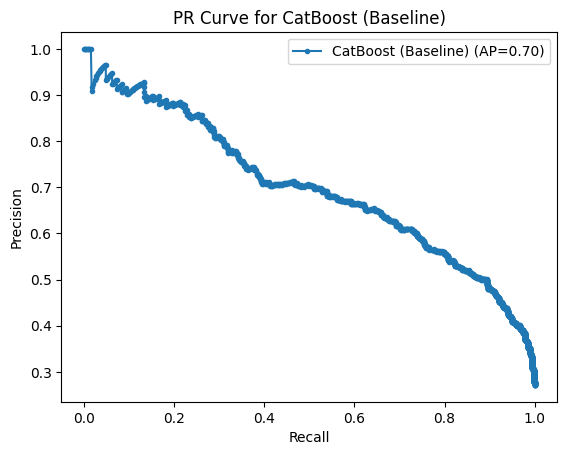

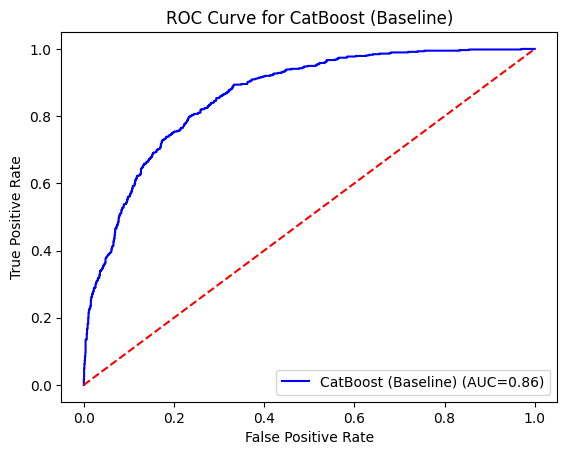

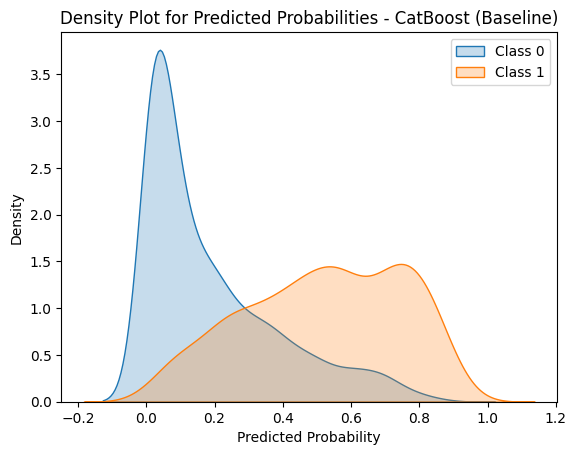

{'Model': 'CatBoost (Baseline)',
 'Accuracy': 0.807382867960246,
 'Precision': 0.6803455723542117,
 'Recall': 0.5487804878048781,
 'F1 Score': 0.6075216972034716,
 'AUC': 0.8613578888504005,
 'Average Precision': 0.7001708187304613}

In [21]:
X1 = df.drop('Churn', axis=1)
y1 = df['Churn']
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=42)

cat_clf = CatBoostClassifier(cat_features=categorical_cols, iterations=100, verbose=0, random_state=42)
cat_clf.fit(X_train1, y_train1)
evaluate_model(cat_clf, X_test1, y_test1, name="CatBoost (Baseline)")

# Perform cross-validation and collect metrics for all models

In [23]:
from sklearn.model_selection import cross_validate

models = [
    {'model': rf_best, 'name': 'Random Forest (Tuned)'},
    {'model': xgb_best, 'name': 'XGBoost (Tuned)'},
    {'model': stack_clf, 'name': 'Stacking Classifier (Baseline)'}
]

cv_results = []
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']

for model in models:
    scores = cross_validate(model['model'], X, y, cv=5, scoring=scoring, return_train_score=False)
    model_results = {'Model': model['name']}
    for metric in scoring:
        model_results[f'CV {metric.capitalize()} Mean'] = scores[f'test_{metric}'].mean()
        model_results[f'CV {metric.capitalize()} Std'] = scores[f'test_{metric}'].std()
    cv_results.append(model_results)

# Cross-validation for CatBoost separately
cbt_scores = cross_validate(cat_clf, X1, y1, cv=5, scoring=scoring, return_train_score=False)
cbt_results = {'Model': 'CatBoost Classifier'}
for metric in scoring:
    cbt_results[f'CV {metric.capitalize()} Mean'] = cbt_scores[f'test_{metric}'].mean()
    cbt_results[f'CV {metric.capitalize()} Std'] = cbt_scores[f'test_{metric}'].std()
cv_results.append(cbt_results)

# Convert results to DataFrame
cv_results_df = pd.DataFrame(cv_results)
print("\nCross-Validation Results:\n", cv_results_df)


Cross-Validation Results:
                             Model  CV Accuracy Mean  CV Accuracy Std  \
0           Random Forest (Tuned)          0.801790         0.012008   
1                 XGBoost (Tuned)          0.804487         0.009594   
2  Stacking Classifier (Baseline)          0.802357         0.009111   
3             CatBoost Classifier          0.801790         0.007645   

   CV Precision Mean  CV Precision Std  CV Recall Mean  CV Recall Std  \
0           0.665716          0.030926        0.509356       0.023555   
1           0.668908          0.024130        0.521673       0.017009   
2           0.675259          0.021233        0.491179       0.024617   
3           0.663630          0.019436        0.513650       0.016414   

   CV F1 Mean  CV F1 Std  CV Roc_auc Mean  CV Roc_auc Std  \
0    0.576958   0.024736         0.842436        0.012520   
1    0.586146   0.019396         0.847623        0.011083   
2    0.568580   0.023248         0.839759        0.008726   
3

In [26]:
display("Cross-Validation Results:", cv_results_df)

'Cross-Validation Results:'

,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std,CV Roc_auc Mean,CV Roc_auc Std,CV Average_precision Mean,CV Average_precision Std
0,Random Forest (Tuned),0.801790,0.012008,0.665716,0.030926,0.509356,0.023555,0.576958,0.024736,0.842436,0.012520,0.662170,0.024053
1,XGBoost (Tuned),0.804487,0.009594,0.668908,0.024130,0.521673,0.017009,0.586146,0.019396,0.847623,0.011083,0.669283,0.022099
2,Stacking Classifier (Baseline),0.802357,0.009111,0.675259,0.021233,0.491179,0.024617,0.568580,0.023248,0.839759,0.008726,0.652958,0.016980
3,CatBoost Classifier,0.801790,0.007645,0.663630,0.019436,0.513650,0.016414,0.578988,0.016118,0.846101,0.010334,0.665147,0.019117


In [39]:
from sklearn.tree import DecisionTreeClassifier
# Cross-validation for base learners separately
base_learners = [
    ('tree', DecisionTreeClassifier(class_weight='balanced')),
    ('Ridge Classifier', RidgeClassifier()),
    ('svc', SVC(C=2.0, kernel='sigmoid', probability=True)),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
]
cv_results_base = []
for name, model in base_learners:
    scores = cross_validate(model, X, y, cv=5, scoring=scoring, return_train_score=False)
    model_results = {'Model': name}
    for metric in scoring:
        model_results[f'CV {metric.capitalize()} Mean'] = scores[f'test_{metric}'].mean()
        model_results[f'CV {metric.capitalize()} Std'] = scores[f'test_{metric}'].std()
    cv_results_base.append(model_results)

In [40]:
cv_results_base_df = pd.DataFrame(cv_results_base)
cv_results_base_df

,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std,CV Roc_auc Mean,CV Roc_auc Std,CV Average_precision Mean,CV Average_precision Std
0,tree,0.731363,0.008297,0.493723,0.016065,0.485810,0.018884,0.489686,0.016881,0.653259,0.011360,0.377478,0.012370
1,Ridge Classifier,0.801931,0.009655,0.660700,0.020290,0.520615,0.028470,0.582187,0.024756,0.837233,0.009801,0.645061,0.021724
2,svc,0.609830,0.027985,0.263673,0.052444,0.262154,0.051931,0.262865,0.052114,0.548720,0.016204,0.283738,0.011959
3,knn,0.753088,0.009660,0.542534,0.023412,0.446762,0.018419,0.489871,0.018907,0.741292,0.014518,0.518773,0.017840
